In [6]:
import numpy as np

from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

img = Image.open("/home/felipe/Desktop/graduation/2025.2/PDI/cap4/projeto_1/data/Fig0338(a)(blurry_moon).tif").convert("L")
print("====== Dimensões da Image ======")
print(f"Altura: {img.size[0]}px Largura: {img.size[1]}px")

====== Dimensões da Image ======
Altura: 466px Largura: 540px


#### Fundamentação Teórica (4.7.3)

Considere os kerneis:

$L_4=\begin{bmatrix}
0 & 1 & 0\\
1 & -4 & 1\\
0 & 1 & 0
\end{bmatrix}$

$L_8=\begin{bmatrix}
1 & 1 & 1\\
1 & -8 & 1\\
1 & 1 & 1
\end{bmatrix}$

Colocando a origem como sendo o centro do kernel ($L_4$):

$h(0,0)=-4$, $h(1,0)=h(0,1)=h(0,-1)=1$

DFT discreta (2D):

$H_4(u,v)=\sum_{x,y}{h(x,y)e^{-2j\pi (\frac{ux}{P}+\frac{vy}{Q})}}$

$H_4(u,v)=-4+2cos(\frac{2\pi u}{P}) + 2cos(\frac{2\pi v}{Q})$

Analogamente, para o kernel $L_8$:

$H_8(u,v)=-8+2cos(\frac{2\pi u}{P}) + 2cos(\frac{2\pi v}{Q}) + 4cos(\frac{2\pi u}{P})cos(\frac{2\pi v}{Q})$

In [7]:
def build_H_filter(P: int, Q: int, kind: str = "4") -> np.ndarray:
    """
        Build frequency-domain Laplacian filter H(u,v) for 4- or 8-neighbour mask.
        args:
            P:
            Q:
            kind: type of kernel available (8 or 4)
        Returns:
            A filter implemented using numpy
    """
    u = np.arange(P)
    v = np.arange(Q)
    U, V = np.meshgrid(u, v, indexing="ij")

    cu = np.cos(2 * np.pi * U / P)
    cv = np.cos(2 * np.pi * V / Q)

    if kind == "4":
        # H4(u,v) = -4 + 2cos(2πu/P) + 2cos(2πv/Q)
        H = -4.0 + 2.0 * cu + 2.0 * cv
    elif kind == "8":
        # H8(u,v) = -8 + 2cos(2πu/P) + 2cos(2πv/Q) + 4cos(2πu/P)cos(2πv/Q)
        H = -8.0 + 2.0 * cu + 2.0 * cv + 4.0 * cu * cv
    else:
        raise ValueError("kind must be '4' or '8'")
    return H

In [8]:
def frequency_filter(img:np.ndarray, kind: str = "4") -> np.ndarray:
    """
        args:
            img: 2D numpy array (MxN), grayscale image.
            kind: type of kernel available (8 or 4)
        Returns:
            2D numpy array (MxN), filtered image.
    """
    # Ensure float for processing
    img = img.astype(np.float64, copy=False)

    # Passo 1: Obtendo os parâmetros P e Q
    M, N = img.shape
    P, Q = 2 * M, 2 * N  # padded dimensions

    # Passo 2: Construir uma imagem preenchida F(x,y) com zeros de tamanho P x Q
    F = np.zeros((P, Q), dtype=np.float64)
    F[:M, :N] = img

    # Passo 3: Multiplicar F(x,y) por (-1)^(x+y).
    x = np.arange(P)
    y = np.arange(Q)
    X, Y = np.meshgrid(x, y, indexing="ij")
    centering_mask = (-1) ** (X + Y)

    F_centered = F * centering_mask

    # Passo 4: Calcular DFT, F(u,v) da F(x,y)
    F_uv = np.fft.fft2(F_centered)

    # Passo 5: Gerar uma função filtro real e simétrica, H(u,v), de tamanho P x Q com centro nas coordenadas (P/2, Q/2). Calcular o produto G(u,v)=H(u,v)*F(u,v)
    H_lap = build_H_filter(P, Q, kind=kind)
    H_sharp = 1.0 - H_lap

    # Aplicar nitidez na frequência: G(u,v) = (1 - H) F(u,v)
    G_uv = H_sharp * F_uv

    # Passo 6: Obtenha a imagem processada -> Gp(x,y)={real[transformada inversa [G(u,v)]]}*(-1)^(x+y).
    g_padded = np.fft.ifft2(G_uv)
    g_padded = np.real(g_padded) * centering_mask

    # Passo 7: Obtenha o resultado processado final, g(x,y), extraindo a região M x N do quadrante superior esquerdo de Gp(x,y).
    g = g_padded[:M, :N]

    # Clipando para plotar depois no range correto
    g = np.clip(g, 0, 255)
    return g.astype(np.uint8)

In [9]:
LAPLACE4 = np.array([[0, 1, 0],
                     [1,-4, 1],
                     [0, 1, 0]], dtype=float)

LAPLACE8 = np.array([[1, 1, 1],
                     [1,-8, 1],
                     [1, 1, 1]], dtype=float)

def laplacian_numpy(img, laplace, pad_mode="reflect"):
    """img: HxW ou HxWxC; retorna float64"""
    img = np.asarray(img, dtype=float)
    if img.ndim == 2:      # grayscale
        return _conv2_valid_pad(img, laplace, pad_mode)
    elif img.ndim == 3:    # RGB/RGBA
        chans = [ _conv2_valid_pad(img[...,c], laplace, pad_mode) for c in range(img.shape[2]) ]
        return np.stack(chans, axis=2)
    else:
        raise ValueError("Imagem deve ser 2D (HxW) ou 3D (HxWxC).")

def _conv2_valid_pad(gray, kernel, pad_mode):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    gp = np.pad(gray, ((ph,ph),(pw,pw)), mode=pad_mode)
    # janelas (H, W, kh, kw)
    win = sliding_window_view(gp, (kh, kw))
    return np.tensordot(win, kernel, axes=((-1,-2),(1,0)))  # mesma forma de gray

In [10]:
def to_uint8_for_display(img: np.ndarray) -> np.ndarray:
    """Normalize to [0, 255] for display."""
    img = img.astype(float)
    mn, mx = img.min(), img.max()
    if mx == mn:
        return np.zeros_like(img, dtype=np.uint8)
    norm = (img - mn) / (mx - mn)
    return (norm * 255).astype(np.uint8)

In [11]:
def sharpen_freq(img: np.ndarray, kind: str = "4") -> np.ndarray:
    """
    Sharpen image using the frequency-domain filter equivalent
    to the Laplacian mask (LAPLACE4 or LAPLACE8).
    Implements: G(u,v) = (1 - H(u,v)) * F(u,v).
    """
    img = np.asarray(img, dtype=float)
    if img.ndim != 2:
        raise ValueError("Only 2D grayscale images are supported.")

    M, N = img.shape

    # DFT of the image
    F = np.fft.fft2(img)

    # Build Laplacian H and sharpening filter 1 - H
    H_lap = build_H_filter(M, N, kind=kind)
    H_sharp = 1.0 - H_lap

    # Apply in frequency
    G = H_sharp * F

    # Inverse DFT
    g = np.fft.ifft2(G)
    g = np.real(g)  # discard numerical imag part

    return g

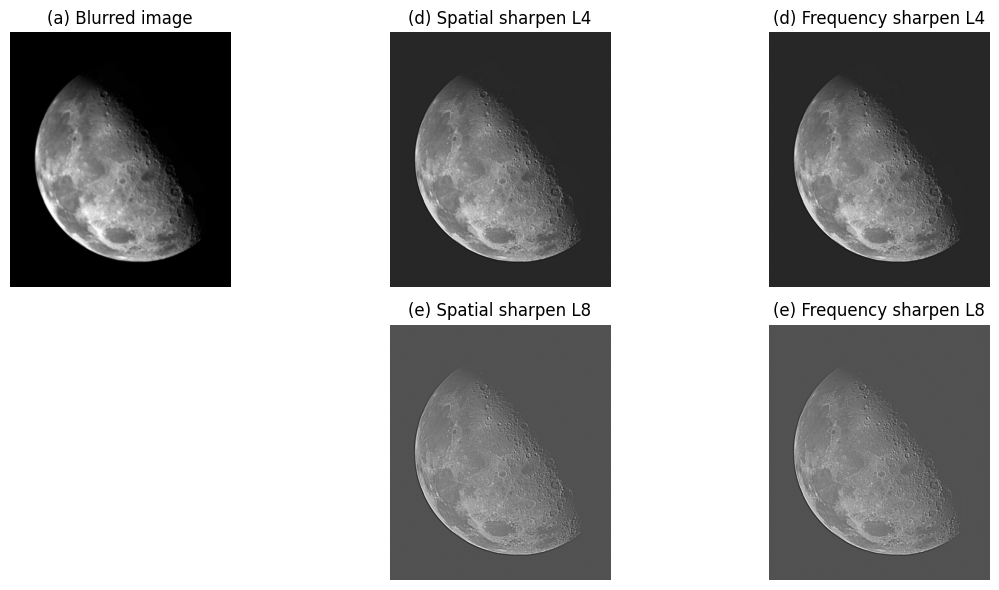

In [15]:
from matplotlib import pyplot as plt


lap4_spatial = laplacian_numpy(img, LAPLACE4)
lap8_spatial = laplacian_numpy(img, LAPLACE8)

img_array = np.array(img)

sharp4_spatial = img_array.astype(float) - lap4_spatial   # Fig. 3.38(d)
sharp8_spatial = img_array.astype(float) - lap8_spatial   # Fig. 3.38(e)

# Domínio da frequência (usando H(u,v) equivalente)
sharp4_freq = sharpen_freq(img_array, kind="4")
sharp8_freq = sharpen_freq(img_array, kind="8")

# Normalização (caso contrário a visualização fica um pouco comprometida)
img_blur_disp   = to_uint8_for_display(img_array)
sharp4_sp_disp  = to_uint8_for_display(sharp4_spatial)
sharp8_sp_disp  = to_uint8_for_display(sharp8_spatial)
sharp4_fr_disp  = to_uint8_for_display(sharp4_freq)
sharp8_fr_disp  = to_uint8_for_display(sharp8_freq)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(img_blur_disp, cmap="gray")
plt.title("(a) Blurred image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(sharp4_sp_disp, cmap="gray")
plt.title("(d) Spatial sharpen L4")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(sharp4_fr_disp, cmap="gray")
plt.title("(d) Frequency sharpen L4")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharp8_sp_disp, cmap="gray")
plt.title("(e) Spatial sharpen L8")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharp8_fr_disp, cmap="gray")
plt.title("(e) Frequency sharpen L8")
plt.axis("off")

plt.tight_layout()
plt.savefig("panel.png")
plt.show()